# EDA e tratamento da base Hillstrom

Este notebook documenta origem, integridade, schema, qualidade e preparação do benchmark randomizado de campanhas. A coluna `segment` representa a ação recebida no experimento e não entra no contexto da política.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd() / "src"))
from datathon.data import load_clean, sha256, source_manifest
from datathon.features import prepare_context

DATA_PATH = Path("data/raw/hillstrom.csv")
FIGURES_PATH = Path("artifacts/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

manifest = source_manifest()
frame = load_clean(DATA_PATH)
dataset_overview = pd.DataFrame(
    {
        "indicador": ["linhas", "colunas", "sha256 esperado", "sha256 observado", "target"],
        "valor": [
            len(frame),
            len(frame.columns),
            manifest["sha256"],
            sha256(DATA_PATH),
            manifest["target"],
        ],
    }
)
display(dataset_overview)

,indicador,valor
0,linhas,64000
1,colunas,14
2,sha256 esperado,0e5893329d8b93cefecc571777672028290ab698657180...
3,sha256 observado,0e5893329d8b93cefecc571777672028290ab698657180...
4,target,conversion


## Qualidade e distribuição experimental

A atribuição próxima de um terço por ação permite replay e avaliação por IPS. `conversion` é o alvo principal; `visit` e `spend` são usados somente como evidências auxiliares de qualidade.

In [2]:
action_summary = (
    frame.groupby("action")
    .agg(
        rows=("action", "size"),
        share=("action", lambda values: len(values) / len(frame)),
        conversion_rate=("conversion", "mean"),
        visit_rate=("visit", "mean"),
        mean_spend=("spend", "mean"),
    )
    .sort_values("conversion_rate", ascending=False)
)
display(
    action_summary.style.format(
        {
            "share": "{:.2%}",
            "conversion_rate": "{:.2%}",
            "visit_rate": "{:.2%}",
            "mean_spend": "${:.2f}",
        }
    )
)

quality = pd.DataFrame(
    {
        "verificação": [
            "valores ausentes",
            "conversões sem visita",
            "ações desconhecidas",
            "perfis completamente repetidos",
        ],
        "ocorrências": [
            int(frame.isna().sum().sum()),
            int((frame["conversion"] > frame["visit"]).sum()),
            int(frame["action"].isna().sum()),
            int(frame.duplicated().sum()),
        ],
    }
)
display(quality)

,rows,share,conversion_rate,visit_rate,mean_spend
action,,,,,
mens_email,21307,33.29%,1.25%,18.28%,$1.42
womens_email,21387,33.42%,0.88%,15.14%,$1.08
no_email,21306,33.29%,0.57%,10.62%,$0.65


,verificação,ocorrências
0,valores ausentes,0
1,conversões sem visita,0
2,ações desconhecidas,0
3,perfis completamente repetidos,6562


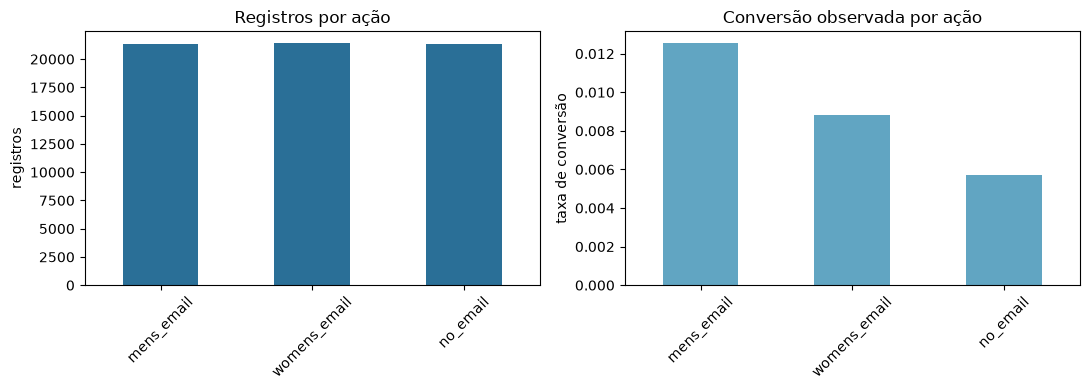

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
action_summary["rows"].plot.bar(ax=axes[0], color="#2a6f97", title="Registros por ação")
action_summary["conversion_rate"].plot.bar(
    ax=axes[1], color="#61a5c2", title="Conversão observada por ação"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("registros")
axes[1].set_xlabel("")
axes[1].set_ylabel("taxa de conversão")
axes[1].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "eda_actions.png", dpi=160, bbox_inches="tight")
plt.show()

## Preparação do contexto

A transformação preserva somente informações disponíveis antes da campanha. Não são usados identificadores pessoais, renda, gênero declarado ou regras comerciais privadas. `mens` e `womens` registram histórico de compra por categoria e não devem ser interpretados como gênero da pessoa.

In [4]:
context = prepare_context(frame)
context_summary = pd.DataFrame(
    {
        "tipo": context.dtypes.astype(str),
        "valores_ausentes": context.isna().sum(),
        "valores_distintos": context.nunique(),
    }
)
display(context.head())
display(context_summary)

,recency,history,mens,womens,newbie,zip_code,channel
0,10,142.44,1,0,0,Surburban,Phone
1,6,329.08,1,1,1,Rural,Web
2,7,180.65,0,1,1,Surburban,Web
3,9,675.83,1,0,1,Rural,Web
4,2,45.34,1,0,0,Urban,Web


,tipo,valores_ausentes,valores_distintos
recency,int64,0,12
history,float64,0,34833
mens,int64,0,2
womens,int64,0,2
newbie,int64,0,2
zip_code,object,0,3
channel,object,0,3


## Conclusão

O arquivo observado corresponde ao checksum versionado e possui as colunas necessárias, sem valores ausentes ou ações inválidas. A base é adequada para comparar uma regra fixa com políticas adaptativas porque registra ação e resultado em grupos randomizados. Ela representa campanhas de varejo; o domínio financeiro desta entrega é uma proposta de aplicação e não uma alegação de desempenho bancário.